In [2]:
import pandas as pd
df=pd.read_csv("data..csv")
df

,X,Y
0,15,49
1,23,63
2,18,58
3,23,60
4,24,58
5,22,61
6,22,60
7,19,63
8,19,60
9,16,52


In [3]:
df.describe()

,X,Y
count,15.000000,15.000000
mean,19.933333,56.800000
std,4.026105,9.056963
min,11.000000,30.000000
25%,17.000000,55.000000
50%,22.000000,60.000000
75%,23.000000,61.500000
max,24.000000,68.000000


In [4]:
df.mean()

X    19.933333
Y    56.800000
dtype: float64

In [5]:
df.isna().sum()

X    0
Y    0
dtype: int64

In [6]:
print(type(df['Y']))

<class 'pandas.core.series.Series'>


In [7]:
x=df.iloc[:,0:1]
y=df.iloc[:,-1]


In [8]:
print(type(x))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [9]:
y

0     49
1     63
2     58
3     60
4     58
5     61
6     60
7     63
8     60
9     52
10    62
11    30
12    59
13    49
14    68
Name: Y, dtype: int64

In [10]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x,y)
y_pred=lr.predict(x)
y_pred

array([47.45652174, 62.60810811, 53.13836663, 62.60810811, 64.5020564 ,
       60.71415981, 60.71415981, 55.03231492, 55.03231492, 49.35047004,
       64.5020564 , 39.88072855, 64.5020564 , 49.35047004, 62.60810811])

In [11]:
diff = pd.DataFrame({"Actual":y,"Predict":y_pred})
diff

,Actual,Predict
0,49,47.456522
1,63,62.608108
2,58,53.138367
3,60,62.608108
4,58,64.502056
5,61,60.714160
6,60,60.714160
7,63,55.032315
8,60,55.032315
9,52,49.350470


In [12]:
print("m: ",lr.coef_)
print("c: ",lr.intercept_)

m:  [1.8939483]
c:  19.047297297297284


In [13]:
from sklearn import metrics
print("MAE: ",metrics.mean_absolute_error(y,y_pred))
print("MSE: ",metrics.mean_squared_error(y,y_pred))
print("R2 Score: ",metrics.r2_score(y,y_pred))

MAE:  3.7412847630238946
MSE:  22.292068155111636
R2 Score:  0.7088287858527738


## After testing

In [14]:
x=df.iloc[:,0:1]
y=df.iloc[:,-1]

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=2)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(11, 1)
(4, 1)
(11,)
(4,)


In [16]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
y_pred

array([47.69491525, 63.55932203, 61.11864407, 52.57627119])

In [17]:
diff = pd.DataFrame({"Actual":y_test,"Predict":y_pred})
diff

,Actual,Predict
11,30,47.694915
4,58,63.559322
5,61,61.118644
0,49,52.576271


In [18]:
print("m: ",lr.coef_)
print("c: ",lr.intercept_)

m:  [1.22033898]
c:  34.271186440677965


In [19]:
from sklearn import metrics
print("MAE: ",metrics.mean_absolute_error(y_test,y_pred))
print("MSE: ",metrics.mean_squared_error(y_test,y_pred))
print("R2 Score: ",metrics.r2_score(y_test,y_pred))

MAE:  6.73728813559322
MSE:  89.20496983625394
R2 Score:  0.3900514882991184


In [23]:
l={}
for i in range(1,43):
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=i)
    lr=LinearRegression()
    lr.fit(x_train,y_train)
    y_pred=lr.predict(x_test)
    l[i]=metrics.mean_absolute_error(y_test,y_pred)
print(min(l.values()))
    
    

0.4198834668608953


In [38]:
import pandas as pd
# x=[1,2,3,4,5,6,7]
# y=[50,55,65,70,75,80,85]
df=pd.DataFrame({'Hours':[1,2,3,4,5,6,7],'Exam Score':[50,55,65,70,75,80,85]})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Hours       7 non-null      int64
 1   Exam Score  7 non-null      int64
dtypes: int64(2)
memory usage: 244.0 bytes


In [39]:
df.describe()

,Hours,Exam Score
count,7.000000,7.000000
mean,4.000000,68.571429
std,2.160247,12.817399
min,1.000000,50.000000
25%,2.500000,60.000000
50%,4.000000,70.000000
75%,5.500000,77.500000
max,7.000000,85.000000


In [43]:
# x=df.iloc[:,0:1]
# y=df.iloc[:,-1]

x=df[['Hours']]
y=df['Exam Score']


print(x.shape)
print(y.shape)

(7, 1)
(7,)


In [44]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x,y)
y_pred=lr.predict(x)
y_pred

array([50.89285714, 56.78571429, 62.67857143, 68.57142857, 74.46428571,
       80.35714286, 86.25      ])

In [46]:
diff=pd.DataFrame({'Actual':y,'Predicted':y_pred})
diff

,Actual,Predicted
0,50,50.892857
1,55,56.785714
2,65,62.678571
3,70,68.571429
4,75,74.464286
5,80,80.357143
6,85,86.250000


In [47]:
print('Co-efficient',lr.coef_)
print('Intercept',lr.intercept_)

Co-efficient [5.89285714]
Intercept 45.0


In [48]:
from sklearn import metrics
print('MAE: ',metrics.mean_absolute_error(y,y_pred))
print('MSE: ',metrics.mean_squared_error(y,y_pred))
print('R2 Score: ',metrics.r2_score(y,y_pred))

MAE:  1.2244897959183672
MSE:  1.9132653061224514
R2 Score:  0.9864130434782609


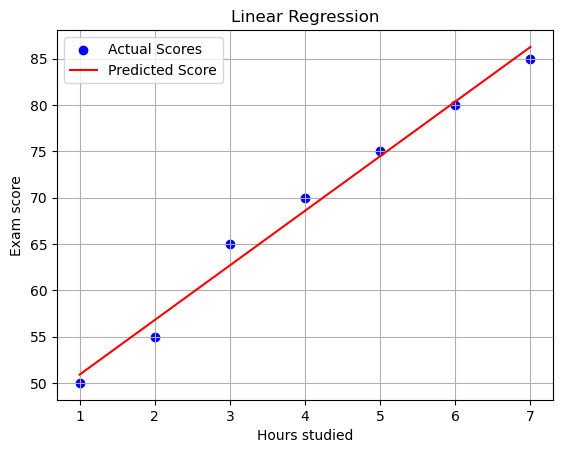

In [49]:
import matplotlib.pyplot as plt
plt.scatter(x,y,color='b',label='Actual Scores')
plt.plot(x,y_pred,color='r',label='Predicted Score')
plt.xlabel('Hours studied')
plt.ylabel('Exam score')
plt.title('Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

In [51]:
df=pd.read_csv('Book1.csv')
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [53]:
df.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


In [55]:
x=df.iloc[:,0:1]
y=df.iloc[:,-1]

In [56]:
print(x.shape)
print(y.shape)

(200, 1)
(200,)


In [62]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(180, 1)
(20, 1)
(180,)
(20,)


In [75]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)

y_pred

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.78737765, 3.13921958, 3.20164315, 2.40148649, 3.52511074,
       3.76345528, 3.16759393, 2.55470798, 3.17894367, 3.49106152,
       1.92479741, 2.3617624 , 3.6840071 , 2.76467817, 3.47403691,
       3.04842166, 2.33906292, 3.20731802, 2.1915163 , 3.31514055])

In [64]:
diff = pd.DataFrame({"Actual":y_test,"Predict":y_pred})
diff

,Actual,Predict
58,3.09,2.955999
40,4.02,4.354192
34,3.42,3.194715
102,1.37,1.938615
184,3.14,3.501636
198,3.96,3.359543
95,2.79,2.791172
4,3.57,2.967367
29,3.49,3.086725
168,3.52,3.939281


In [65]:
print("m: ",lr.coef_)
print("c: ",lr.intercept_)

m:  [0.56837096]
c:  -0.9771275542729962


In [66]:
from sklearn import metrics
print("MAE: ",metrics.mean_absolute_error(y_test,y_pred))
print("MSE: ",metrics.mean_squared_error(y_test,y_pred))
print("R2 Score: ",metrics.r2_score(y_test,y_pred))

MAE:  0.2407378157739672
MSE:  0.09630812755183496
R2 Score:  0.7763411228752372


In [67]:
l={}
for i in range(1,43):
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=i)
    lr=LinearRegression()
    lr.fit(x_train,y_train)
    y_pred=lr.predict(x_test)
    l[i]=metrics.mean_absolute_error(y_test,y_pred)
print(min(l.values()))

0.1900674770114435


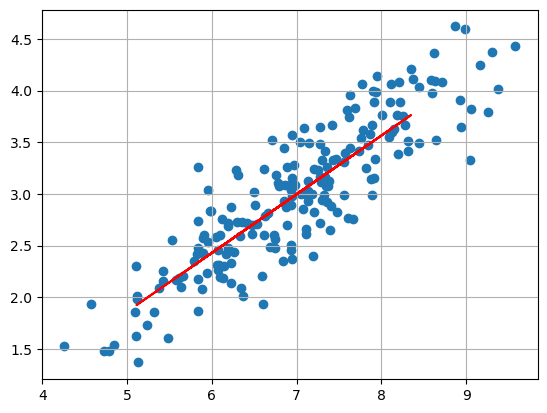

In [70]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(x_test,y_pred,color='red')
plt.grid(True)
plt.show()

<Axes: xlabel='cgpa', ylabel='package'>

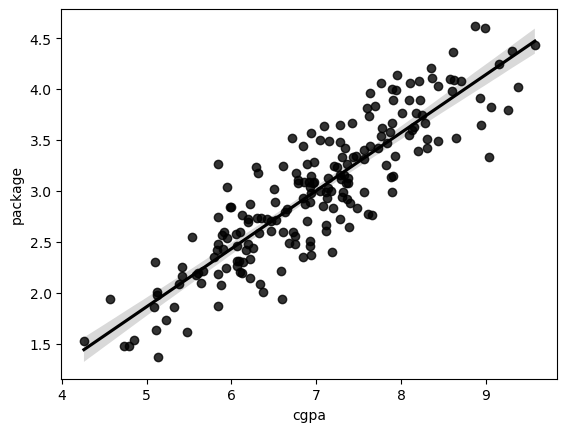

In [73]:
import seaborn as sns
sns.regplot(data=df,x='cgpa',y='package',color='k')

In [78]:
ypred= lr.predict([[8.5]])
ypred

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.84857833])

## Multiple Linear Regression

In [100]:
df=pd.read_csv('car data.csv')
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [101]:
df['Car_Name'].nunique()

98

In [102]:
df.nunique()

Car_Name          98
Year              16
Selling_Price    156
Present_Price    147
Kms_Driven       206
Fuel_Type          3
Seller_Type        2
Transmission       2
Owner              3
dtype: int64

In [103]:
df=df.drop(columns='Car_Name')

In [104]:
df['Age']=2026-df['Year']

In [105]:
df=df.drop(columns='Year')
df

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [106]:
df=pd.get_dummies(df,columns=['Fuel_Type','Seller_Type','Transmission'],drop_first=True)
df

,Selling_Price,Present_Price,Kms_Driven,Owner,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,0,10,True,False,False,True
297,4.00,5.90,60000,0,11,False,True,False,True
298,3.35,11.00,87934,0,17,False,True,False,True
299,11.50,12.50,9000,0,9,True,False,False,True


In [ ]:
#   OR  df=pd.get_dummies(data=df,drop_first=True)

In [107]:
df.columns

Index(['Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner', 'Age',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual',
       'Transmission_Manual'],
      dtype='object')

In [109]:
Y=df['Selling_Price']
X=df.drop('Selling_Price',axis=1)

In [111]:
X.shape

(301, 8)

In [114]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=1)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(240, 8)
(61, 8)
(240,)
(61,)


In [ ]:
# CONTINUE..... 